# Plots Paper

In this notebook, we produce the plots of the paper

In [152]:
import os
import matplotlib.pyplot as plt
import h5py
import numpy as np
import healpy as hp
from matplotlib.colors import LogNorm

# results_dir = 'segwo_results/static/'
# results_dir = 'segwo_results/static_boost0.0/'
results_dir = 'segwo_results/15.0days_evolving_boost1.0/'
results_dir = 'segwo_results/15.0days_evolving_boost0.0/'

output_dir = results_dir.rstrip('/') + '/'
hdf5_path  = os.path.join(output_dir, "results.h5")
output_dir, hdf5_path

pols=(r'$h_+$', r'$h_\times$')

In [153]:
print(f"Loading results from {hdf5_path} …")
with h5py.File(hdf5_path, "r") as hf:
    f         = hf["metadata/frequencies"][()]
    betas     = hf["metadata/betas"][()]
    lambs     = hf["metadata/lambs"][()]
    nside     = int(hf["metadata"].attrs["nside"])
    npix      = int(hf["metadata"].attrs["npix"])
    run_flag  = str(hf["metadata"].attrs["run_flag"])

    strain2x_nominal = (hf["nominal/strain2x_real"][()] +
                        1j * hf["nominal/strain2x_imag"][()])

    ltt_residuals      = hf["perturbed/ltt_residuals"][()]
    position_residuals = hf["perturbed/position_residuals"][()]

    strain2x_abs_error   = hf["errors/strain2x_abs_error"][()]
    strain2x_angle_error = hf["errors/strain2x_angle_error"][()]
    mismatch             = hf["errors/mismatch"][()]
    amp_violation_ratio   = float(hf["errors"].attrs["amp_violation_ratio"])
    phase_violation_ratio = float(hf["errors"].attrs["phase_violation_ratio"])

print(f"  run_flag                 : {run_flag}")


Loading results from segwo_results/15.0days_evolving_boost0.0/results.h5 …
  run_flag                 : evolving


# Mismatch Analysis

In [154]:
nan_mask = np.isnan(mismatch)
print(f"  Number of NaN values in {pols[0]}: {nan_mask.sum(axis=(0,1,2))[0]} out of {mismatch.size}")
print(f"  Number of NaN values in {pols[1]}: {nan_mask.sum(axis=(0,1,2))[1]} out of {mismatch.size}")
metric_func = np.max

  Number of NaN values in $h_+$: 0 out of 129600000
  Number of NaN values in $h_\times$: 0 out of 129600000


<Figure size 640x480 with 0 Axes>

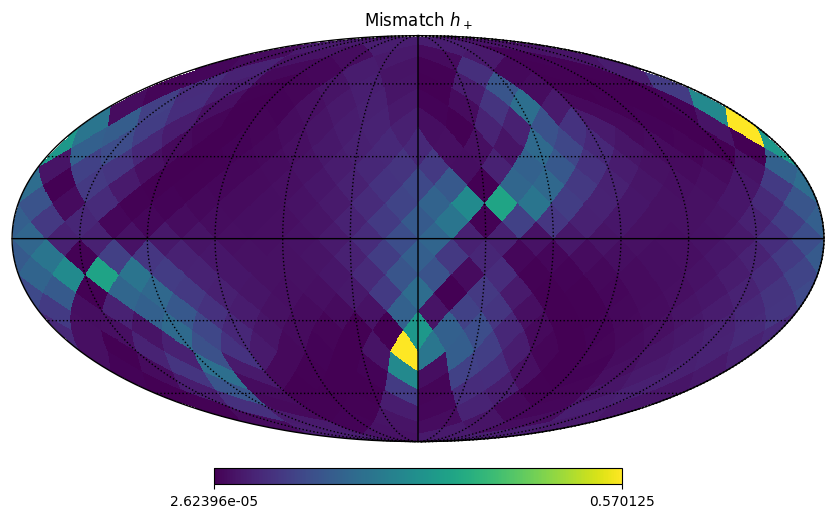

<Figure size 640x480 with 0 Axes>

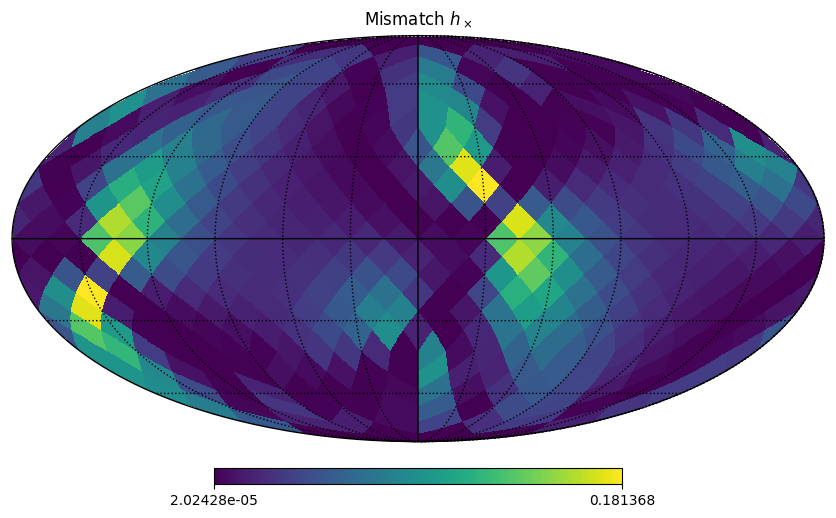

In [155]:
# mismatch over sky max across frequencies and realizations
response_map = metric_func(mismatch,axis=(0,1))
for pol in range(2):
    plt.figure()
    hp.mollview(response_map[...,pol],title=f"Mismatch {pols[pol]}",rot=[0, 0])
    hp.graticule()
    

(150, 2)


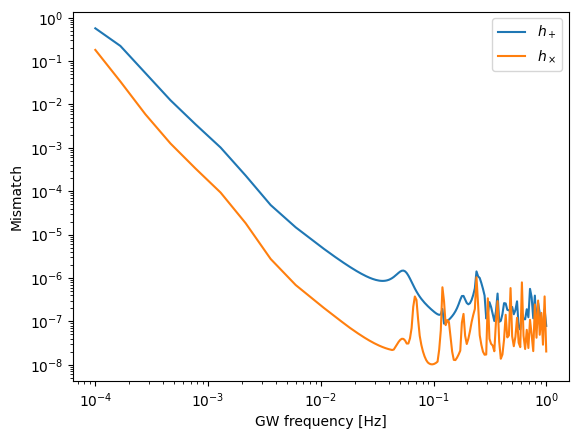

In [156]:
mismatch[nan_mask] = 0.0
frequency_map = metric_func(mismatch,axis=(0,2))
print(frequency_map.shape)
plt.figure()
for j in range(2):
    plt.loglog(f, frequency_map[...,j], label=f'{pols[j]}')
plt.legend()
plt.xlabel("GW frequency [Hz]")
plt.ylabel("Mismatch")
plt.legend()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_85902/1644415125.py:15: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label("Mismatch $\mathcal{M}$")


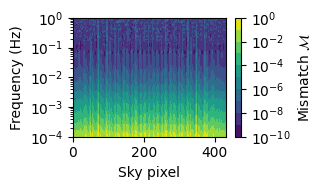

In [157]:
pol = 0
z = metric_func(mismatch,axis=(0))[..., pol]
vmin = 1e-10 #np.max([1e-10,z.min()])
vmax = 1.0 #np.min([1.0,z.max()])
z[z<vmin] = vmin
z[z>vmax] = vmax

dmin = np.floor(np.log10(vmin)) # down to lower decade
dmax = np.ceil(np.log10(vmax)) # up to upper decade
levels = np.logspace(dmin, dmax, num=int(dmax - dmin + 1))
plt.figure(figsize=(3.25, 2))
cf = plt.contourf(np.arange(z.shape[1]), f, z, levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax),cmap="viridis")
plt.yscale("log")  # same as semilogy for axis scaling
cbar = plt.colorbar(cf)
cbar.set_label("Mismatch $\mathcal{M}$")
plt.xlabel("Sky pixel")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mismatch_contour.png"), dpi=300)
plt.show()